# Preprocessing dan Training Model 3 (Anomaly Detector)

## Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/bus_anomaly_dataset.csv")
print(df.shape)
print(df.info())
print(df.isna().sum())

(1836000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1836000 entries, 0 to 1835999
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   bus_id           str    
 1   route_id         str    
 2   day              int64  
 3   timestamp        str    
 4   hour             int64  
 5   speed_kmh        float64
 6   passenger_count  int64  
 7   engine_temp_c    float64
 8   rolling_mean_1h  float64
 9   rolling_std_1h   float64
 10  z_score          float64
 11  is_anomaly       int64  
 12  anomaly_type     str    
 13  severity         str    
dtypes: float64(5), int64(4), str(5)
memory usage: 196.1 MB
None
bus_id              0
route_id            0
day                 0
timestamp           0
hour                0
speed_kmh           0
passenger_count     0
engine_temp_c       0
rolling_mean_1h     0
rolling_std_1h     30
z_score             0
is_anomaly          0
anomaly_type        0
severity            0
dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['speed_kmh', 'passenger_count', 'engine_temp_c', 'rolling_mean_1h', 'z_score']

X = df[features]
y = df['is_anomaly'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y,          
    random_state=42      
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dari dataset Model 3 yang terdiri dari 1.836.000 baris, dipilih lima fitur input yaitu speed_kmh, passenger_count, engine_temp_c, rolling_mean_1h, dan z_score. Kolom identitas dan metadata (bus_id, route_id, day, timestamp, hour) serta kolom bantu (rolling_std_1h) dan label ground truth (is_anomaly, anomaly_type, severity) tidak diikutsertakan sebagai fitur dan label hanya digunakan pada tahap evaluasi. Dataset kemudian dibagi menjadi train dan test dengan rasio 80:20 menggunakan stratify pada is_anomaly untuk memastikan proporsi anomali sebesar 5% terjaga di kedua subset. StandardScaler di-fit eksklusif pada data train kemudian diterapkan ke data test untuk menghindari data leakage, menyelaraskan skala antar fitur sebelum masuk ke model Isolation Forest.

## Training

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

if_model = IsolationForest(random_state=42)
if_model.fit(X_train_scaled)

if_pred = if_model.predict(X_test_scaled)
if_pred = [1 if x == -1 else 0 for x in if_pred]

print(classification_report(y_test, if_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    348839
           1       0.35      0.94      0.51     18361

    accuracy                           0.91    367200
   macro avg       0.67      0.93      0.73    367200
weighted avg       0.96      0.91      0.93    367200



Model Isolation Forest dilatih secara unsupervised dengan parameter contamination sebesar 0.05 sesuai proporsi anomali aktual pada dataset. Model mencapai recall kelas anomali sebesar 0.94, artinya 94% kejadian anomali berhasil terdeteksi. Precision kelas anomali sebesar 0.35 terlihat rendah, namun ini merupakan konsekuensi wajar dari ketidakseimbangan kelas (5% anomali) dimana precision kelas normal yang mendekati 1.00 bukan indikator model terlalu sempurna, melainkan artefak matematis karena jumlah false negative anomali sangat kecil relatif terhadap 348.000+ baris normal.

In [4]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report
import numpy as np

knn = NearestNeighbors(n_neighbors=5)
knn = knn.fit(X_train_scaled)

train_distances, _ = knn.kneighbors(X_train_scaled)
train_anomaly_scores = np.mean(train_distances, axis=1)
threshold = np.percentile(train_anomaly_scores, 95)

test_distances, _ = knn.kneighbors(X_test_scaled)
test_anomaly_scores = np.mean(test_distances, axis=1)

knn_pred = [1 if score > threshold else 0 for score in test_anomaly_scores]
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96    348839
           1       0.34      0.66      0.45     18361

    accuracy                           0.92    367200
   macro avg       0.66      0.80      0.70    367200
weighted avg       0.95      0.92      0.93    367200



Sebagai pembanding, digunakan KNN (k-Nearest Neighbors) dengan n_neighbors=5 di mana anomaly score dihitung berdasarkan rata-rata jarak ke 5 tetangga terdekat dengan threshold pada persentil ke-95. KNN mencapai recall kelas anomali 0.66 yang jauh di bawah Isolation Forest (0.94), artinya sepertiga anomali aktual tidak terdeteksi. Meskipun accuracy keseluruhan (0.92) sedikit lebih tinggi dari IF (0.91), angka ini menyesatkan karena didominasi oleh kelas normal yang mayoritas. 

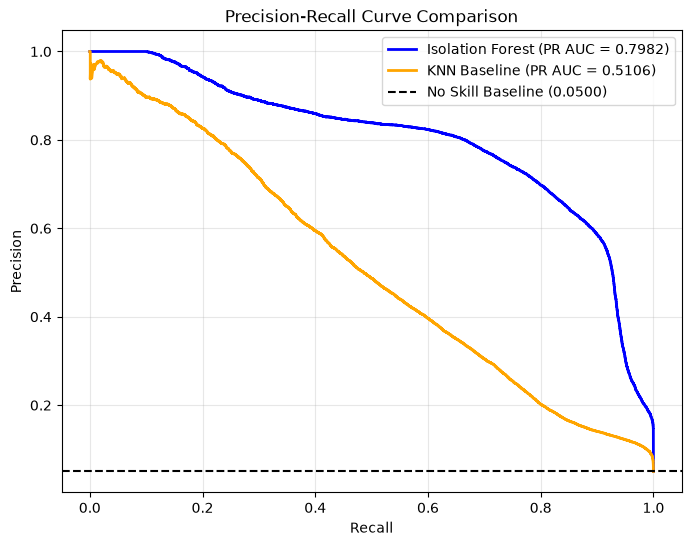

PR AUC Isolation Forest: 0.7982
PR AUC KNN Baseline     : 0.5106


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

if_scores = -if_model.score_samples(X_test_scaled)
knn_scores = test_anomaly_scores

if_precision, if_recall, _ = precision_recall_curve(y_test, if_scores)
if_pr_auc = auc(if_recall, if_precision)

knn_precision, knn_recall, _ = precision_recall_curve(y_test, knn_scores)
knn_pr_auc = auc(knn_recall, knn_precision)

plt.figure(figsize=(8, 6))
plt.plot(if_recall, if_precision, label=f'Isolation Forest (PR AUC = {if_pr_auc:.4f})', color='blue', lw=2)
plt.plot(knn_recall, knn_precision, label=f'KNN Baseline (PR AUC = {knn_pr_auc:.4f})', color='orange', lw=2)

no_skill = sum(y_test) / len(y_test)
plt.axhline(y=no_skill, color='black', linestyle='--', label=f'No Skill Baseline ({no_skill:.4f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

print(f"PR AUC Isolation Forest: {if_pr_auc:.4f}")
print(f"PR AUC KNN Baseline     : {knn_pr_auc:.4f}")

Evaluasi menggunakan Precision-Recall (PR) AUC dipilih sebagai metrik utama karena ROC AUC cenderung optimistis pada kondisi class imbalance dan kurang mencerminkan performa sesungguhnya pada kelas minoritas. Isolation Forest menghasilkan PR AUC 0.7982 dengan kurva yang hampir datar di precision ~1.00 hingga recall 0.60, artinya model mampu menangkap 60% anomali dengan hampir nol false positive sebelum mulai mengalami trade-off. KNN baseline hanya mencapai PR AUC 0.5106 dengan degradasi precision yang terjadi sejak awal kurva. Selisih PR AUC sebesar ~0.29 antara kedua model merupakan margin yang signifikan dan memperkuat keputusan penggunaan Isolation Forest sebagai model final.

In [7]:
import joblib

joblib.dump(scaler, 'model3_scaler.pkl')
joblib.dump(if_model, 'model3_anomaly_detector.pkl')

['model3_anomaly_detector.pkl']

Output predict() Isolation Forest hanya menghasilkan label biner (-1/1) yang tidak cukup untuk memenuhi spesifikasi yang diinginkan, yakni anomaly_score dan severity sebagai output endpoint. Untuk itu, digunakan score_samples() yang menghasilkan skor kontinu per baris. 

In [4]:
import joblib

scaler = joblib.load('../models/model3_scaler.pkl')
X_test_scaled = scaler.transform(X_test)

model = joblib.load('../models/model3_anomaly_detector.pkl')
scores = -model.score_samples(X_test_scaled)
scores[:10]

array([0.42181433, 0.45539051, 0.54567233, 0.36788604, 0.59890391,
       0.34805229, 0.46375303, 0.41965506, 0.48135115, 0.38533244])

In [5]:
X_train_scaled = scaler.transform(X_train)
train_scores = -model.score_samples(X_train_scaled)

p95 = np.percentile(train_scores, 95)
p97 = np.percentile(train_scores, 97)
p99 = np.percentile(train_scores, 99)

print(p95, p97, p99)

0.570353655280716 0.6007893136710493 0.633819694163295


Cutoff persentil dihitung dari distribusi score_samples() pada train set bukan test set untuk menghindari data leakage pada proses kalibrasi threshold. Pendekatan persentil dipilih karena memiliki hubungan langsung dengan parameter contamination=0.05 yang sudah ditetapkan ~5% data teratas berdasarkan anomaly score adalah yang di-flag sebagai anomali oleh model, sehingga severity tier cukup membagi 5% tersebut lebih lanjut tanpa menggunakan angka sembarang. Hasilnya: persentil ke-95 = 0.5704, persentil ke-97 = 0.6008, persentil ke-99 = 0.6338. 

In [6]:
import numpy as np

def assign_severity(score):
    if score >= p99:
        return 'High'
    elif score >= p97:
        return 'Medium'
    elif score >= p95:
        return 'Low'
    else:
        return None

test_df = X_test.copy()
test_df['anomaly_score'] = scores
test_df['severity'] = test_df['anomaly_score'].apply(assign_severity)
test_df['is_anomaly'] = y_test.values
test_df['anomaly_type'] = df.loc[X_test.index, 'anomaly_type'].values

anomaly_only = test_df[test_df['is_anomaly'] == 1]
print(anomaly_only.groupby('anomaly_type')['severity'].value_counts(normalize=True).round(3))

anomaly_type        severity
kecelakaan          Medium      0.510
                    Low         0.337
                    High        0.152
mogok               Medium      0.586
                    High        0.247
                    Low         0.167
overheat            Low         0.797
                    Medium      0.153
                    High        0.051
overloaded          Low         0.733
                    Medium      0.221
                    High        0.046
overspeed           Low         0.706
                    Medium      0.249
                    High        0.045
sensor_malfunction  High        1.000
Name: proportion, dtype: float64


Untuk memverifikasi apakah tingkat severity yang dihasilkan memiliki makna semantik, dilakukan validasi silang antara severity yang di-assign model dengan anomaly_type ground truth pada subset anomali di test set (n=18.361). Hasilnya sebagian konsisten, sensor_malfunction jatuh 100% di tier High (n=1.348, cukup besar untuk dianggap robust), kecelakaan dan mogok dominan di Medium/High yang wajar karena speed=0 di tengah distribusi data yang mayoritas bergerak. Sebaliknya, overheat, overloaded, dan overspeed mayoritas jatuh di tier Low (70–80%) meski secara operasional termasuk insiden serius. Ini merupakan karakteristik inheren Isolation Forest dimana model mengukur derajat keterisolasian di ruang fitur gabungan, bukan severity operasional, sehingga deviasi speed=0 lebih "asing" secara statistik dibanding deviasi suhu tinggi atau kepadatan berlebih. Dengan demikian, severity yang dihasilkan merepresentasikan isolation degree, bukan tingkat bahaya insiden sesungguhnya, dan harus diinterpretasikan dalam konteks tersebut.

In [7]:
print(anomaly_only['anomaly_type'].value_counts())

anomaly_type
mogok                 7695
overheat              3857
overloaded            2401
overspeed             1971
sensor_malfunction    1348
kecelakaan            1089
Name: count, dtype: int64


In [9]:
config = {
    "contamination": 0.05,
    "features": ["speed_kmh", "passenger_count", "engine_temp_c", "rolling_mean_1h", "z_score"],
    "anomaly_label_mapping": {"IF_output_-1": 1, "IF_output_1": 0},
    "severity_thresholds": {
        "High": p99,
        "Medium": p97,
        "Low": p95
    },
    "scaler": "scaler_model3.pkl",
    "model": "model3_anomaly_detector.pkl"
}

import json
with open('./model3_config.json', 'w') as f:
    json.dump(config, f, indent=2)